---
title: "Generating your own travel time matrices for routing problems"
image: image.png
toc: true
execute: 
  enabled: false
---

There are a wide range of options for generating your own travel time matrices, including various travel time APIs. 

You can find an example of how to use the routingpy package, which supports a wide range of APIs, here: https://geographic.hsma.co.uk/mtt_travel_time_apis.html

Some good options are the r5py and valhalla packages. 

These takes an output from the open street map project.

Because you're running this locally, you aren't contending with the number of requests you can make to the online services (API rate limits). 

Today, we're going to use valhalla as we're focussing on car travel times and it is more focussed on accurate car travel than r5py, which excels at walking, cycling and public transport. 

::::{.callout-tip}

You can take a look at an example with r5py for both car and public tranport [here](../../location/obtaining_travel_time_matrices/index.ipynb).

And you can take a look at a comparison of r5py and valhalla, and how they respond to modifications to maximum road speeds in the osm file, [here](../../other/modifying_osm_max_speeds/index.ipynb).

::::





We'll kick off with a couple of standard imports. 

In [2]:
import geopandas
import contextily as cx

Let's start by importing our data to set up a transport network. 

In [3]:
from lokigi.travel_utils import prepare_valhalla_network, build_time_matrix_valhalla

We'll then process our osm.pbf file for use with valhalla.

In [4]:
prepare_valhalla_network(
    osm_path="../../datasets/devon-260422.osm.pbf",
    output_dir="../../datasets/",
    output_name="devon-260422_valhalla.json"
)

Using existing Valhalla build


{'config_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla.json.json',
 'tile_dir': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla.json_tiles',
 'traffic_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla.json_traffic.tar'}

Next we need to grab our sources (where our nurses will travel from). Because they will go between patient visits, not return to base each time, it's best if we include every possible combination of locations that a nurse could conceivably travel to and from.  

We'll use postcodes centroids for this. 


:::{.callout-note}
We've obtained this by filtering the ONSPD Online Latest Centroids available via the UK government geoportal and downloading the filtered dataset. 

The dataset is available here: [https://geoportal.statistics.gov.uk/datasets/ons::onspd-online-latest-centroids-1](https://geoportal.statistics.gov.uk/datasets/ons::onspd-online-latest-centroids-1)



We've zoomed the map and selected 'filter as map moves' to limit the number of records somewhat, and then ensured 'toggle filters' is selected before downloading. 
:::



:::{.callout-note}
Source: Office for National Statistics licensed under the Open Government Licence v.3.0
Contains OS data © Crown copyright and database right 2026
:::

In [5]:
postcode_centroids = geopandas.read_file("../../datasets/ONSPD_Online_Latest_Centroids_-8786573295356178222.gpkg")

In [6]:
postcode_centroids.head()

,PCD7,PCD8,PCDS,DOINTR,DOTERM,CTY25CD,CED25CD,LAD25CD,WD25CD,PARNCP25CD,...,ICB23CD,OA21CD,LSOA21CD,MSOA21CD,RUC21IND,F_matched_characters,F_matched_parts___part,F_matched_parts___startIndex,GlobalID,geometry
0,PL159TP,PL15 9TP,PL15 9TP,200804,NaN,E99999999,E99999999,E06000052,E05013844,E04011406,...,E54000036,E00095833,E01018974,E02003932,RSF1,None,None,NaN,{2EBC9115-8D94-4842-985E-68713197A179},POINT (231734 91748)
1,PL158WQ,PL15 8WQ,PL15 8WQ,200401,201211,E99999999,E99999999,E06000052,E05013837,E04013094,...,E54000036,E00095782,E01018965,E02003936,RSF1,None,None,NaN,{31A0AD82-62EF-4EFE-BD6F-F731450D774D},POINT (231780 83565)
2,PL157XP,PL15 7XP,PL15 7XP,199712,199906,E99999999,E99999999,E06000052,E05013837,E04013094,...,E54000036,E00095782,E01018965,E02003936,RSF1,None,None,NaN,{B19932C6-DCF5-42CA-A309-2E23E8FB132E},POINT (228455 81741)
3,PL159PY,PL15 9PY,PL15 9PY,198001,200401,E99999999,E99999999,E06000052,E05013837,E04011470,...,E54000036,E00095784,E01018966,E02003936,RSF1,None,None,NaN,{3801CC30-3A0F-4012-B9FA-35896FFD3601},POINT (234571 77542)
4,PL178LB,PL17 8LB,PL17 8LB,198001,NaN,E99999999,E99999999,E06000052,E05013837,E04011589,...,E54000036,E00095787,E01018967,E02003936,RSF1,None,None,NaN,{9BEB33DE-00A1-41E3-8E26-768BD8FB4CD1},POINT (236888 73895)


Let's plot these on an interactive map to check them out. 

<Axes: >

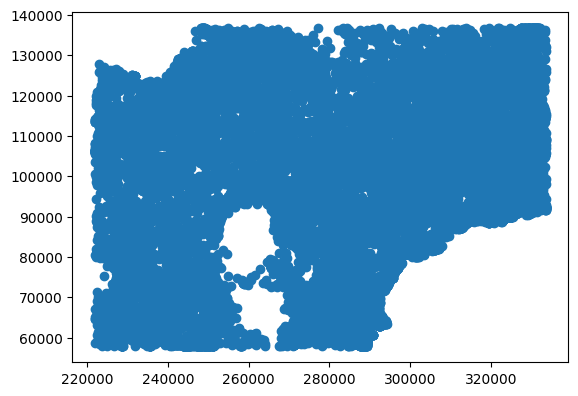

In [7]:
postcode_centroids.plot()

Let's imagine we've been told the team cover TQ postcodes only. 

We use a regular expression here, with the string r"^TQ" matching postcodes that start with TQ - ignoring any where TQ is elsewhere in the postcode. 

So e.g. 

- TQ4 6AH would be included
- EX16 2TQ would not

In [8]:
postcode_centroids_filtered = postcode_centroids[
    postcode_centroids["PCD7"].str.contains(r"^TQ")
    ].copy()

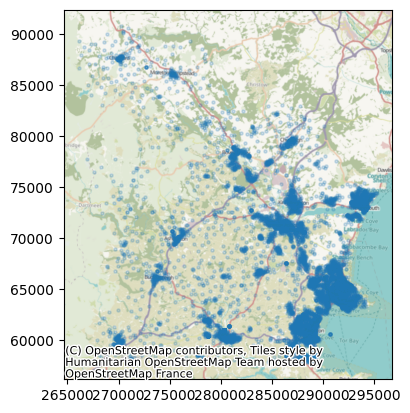

In [9]:
ax = postcode_centroids_filtered.plot(alpha=0.2, markersize=5,)

cx.add_basemap(
    ax,
    crs=postcode_centroids_filtered.crs.to_string(),
    )

We can see that we've effectively filtered down our dataset. How many postcodes does this leave? 

In [10]:
len(postcode_centroids_filtered)

10317

How many combinations will this be? 

In [11]:
f"{len(postcode_centroids_filtered)*len(postcode_centroids_filtered):,}"

'106,440,489'

That's quite a lot of combinations! 
Let's see how valhalla handles it. 

Let's now convert it from BNH (Northings/Eastings) to latitude and longitude to match our other data (and what valhalla expects). 

We'll rename our PCD7 (postcode) column to 'id'.

We'll also just get rid of the columns we're not using, and reset the index to tidy up after our earlier filtering. 

In [12]:
postcode_centroids_filtered = (
    postcode_centroids_filtered.to_crs('EPSG:4326').rename(columns={'PCD7':'id'})
    )[["id", "geometry"]].reset_index(drop=True)

In [13]:
postcode_centroids_filtered.head(5)

,id,geometry
0,TQ4 5RS,POINT (-3.57252 50.42742)
1,TQ3 3AH,POINT (-3.57087 50.43668)
2,TQ3 3SR,POINT (-3.58489 50.44288)
3,TQ4 7EN,POINT (-3.58838 50.42337)
4,TQ3 1YD,POINT (-3.56731 50.43675)


## Generating the matrix

### Car travel 

Let's just try the first 1000. That's still a lot of combinations:

In [15]:
f"{len(postcode_centroids_filtered.head(1000))} postcodes = {len(postcode_centroids_filtered.head(1000))*len(postcode_centroids_filtered.head(1000)):,} combinations"

'1000 postcodes = 1,000,000 combinations'

In [13]:
travel_time_matrix_car_valhalla = build_time_matrix_valhalla(
    origins_gdf=postcode_centroids_filtered.head(1000),
    destinations_gdf=postcode_centroids_filtered.head(1000),
    valhalla_config_path="../../datasets/devon-260422_valhalla-combined-modified.json",
    output_csv_path="../../../sample_data/torquay_all_postcodes_to_all_travel_matrix_car.csv",
    costing="auto" # This means car, not 'automatic'!
)

Streaming Long Matrix:   0%|          | 0/20 [00:00<?, ?it/s]

Streaming Long Matrix: 100%|██████████| 20/20 [10:52<00:00, 32.64s/it]

Matrix generation complete. Output saved to ../../../sample_data/torquay_all_postcodes_to_all_travel_matrix_car.csv


Now, this took 11 minutes to create a 30mb csv with 1 million rows. 

However, we know we have 106 million total combinations to calculate. 

So assuming it scales roughly linearly...

That's about 19.5 hours for a file that's likely to be several gigabytes in size. 

What about if we needed to be able to do the whole of Devon? Or beyond? 

Roughly 30,000 postcodes across the whole of Devon would lead to 900 million combinations to calculate. This is going to be closer to 30gb and might take nearly 7 days to run. Even if we consider ways to avoid this like assuming pairwise journey equivalency (i.e. journeys are assumed to be the same distance/time in each direction) 

:::{.callout-tip}
If you find yourself needing this level of detail, you're probably doing a different kind of routing problem to the site location stuff lokigi focussed on. You could consider using Valhalla on-the-fly to evaluate travel times (for example, if you're doing a discrete event simulation and want to calculate travel times as you go along). 

If you absolutely need a travel matrix, you'll have to accept some long waits! Or you could try chunking it up and parallelising the task. However, you'd still need to then think of some smarter ways to handle the very large resulting dataframe, and lokigi would not support this. 

If you're doing a location allocation problem, we'd simply suggest for now using larger units of area. 

In England, for example, there are roughly

1,500,000 postcodes
175,000 OAs
30,000 LSOAs
7000 MSOAs

So OAs might be a good enough alternative to postcode-to-postcode travel times for site optimisation problems. 
:::